# Survival Analysis — Customer Churn

---

## Project Overview

**Objective:** Understand *when* and *why* customers churn using survival analysis techniques.
Complements the binary classification model in `3a)Data_Preprocessing_Models_Churn` by adding a temporal dimension.

**Data:** `mask_pay` — customers with at least one settlement event (67,440 customers).
Every customer in this population has a known outcome and duration, making censoring a non-issue.

| Variable | Description |
|----------|-------------|
| `TIME_TO_CHURN_D` | Duration of last contract until settlement (days) |
| `IS_CHURN` | Event indicator: 1 = churned, 0 = returned within 30 days (censored) |

---

## Notebook Structure

```
 0. SET UP                  Imports, constants, paths
 1. LOAD DATASET            Load ABT, filter to mask_pay
 2. KAPLAN-MEIER            Overall survival curve + group comparisons
 3. COX PH MODEL            Hazard ratios per feature
 4. SUMMARY                 Key findings
```

---
## 0. SET UP
---

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import src.code.io_utils as io_utils

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

CLIENT_PATH = io_utils.output_path('prepared/abt.parquet')

---
## 1. LOAD DATASET
---

In [2]:
abt = io_utils.load(CLIENT_PATH)

# Filter to customers with settlement history (training population)
mask_pay = abt[abt[["EVER_SAN", "EVER_SOL", "EVER_RBT"]].eq(1).any(axis=1)].copy()

print(f"Total ABT:   {len(abt):,}")
print(f"mask_pay:    {len(mask_pay):,}")
print(f"IS_CHURN=1:  {mask_pay['IS_CHURN'].sum():,}  ({mask_pay['IS_CHURN'].mean():.1%})")
print(f"IS_CHURN=0:  {(mask_pay['IS_CHURN']==0).sum():,}  ({(mask_pay['IS_CHURN']==0).mean():.1%})")
print()
print("TIME_TO_CHURN_D stats (churned only):")
print(mask_pay.loc[mask_pay['IS_CHURN']==1, 'TIME_TO_CHURN_D'].describe().round(1))

[LOAD] /Users/eliaskarle/Coding/Nova/BusinessCases_1/Business_Case_BNP/data/prepared/abt.parquet | shape: (148729, 91)
Total ABT:   148,729
mask_pay:    67,440
IS_CHURN=1:  66,322  (98.3%)
IS_CHURN=0:  1,118  (1.7%)

TIME_TO_CHURN_D stats (churned only):
count    66322.0
mean      1313.7
std       1610.4
min          0.0
25%        168.0
50%        839.0
75%       1848.0
max      10140.0
Name: TIME_TO_CHURN_D, dtype: float64


---
## 2. KAPLAN-MEIER
---

### Concept

The **Kaplan-Meier (KM) estimator** is a non-parametric method for estimating the *survival function* — the probability that a customer has not yet churned by time *t*.

$$S(t) = P(T > t)$$

Where $T$ is the time until the churn event occurs.

**Key properties:**
- **Non-parametric** — makes no assumption about the shape of the survival distribution.
- **Handles censoring** — customers who have not yet churned by the observation cutoff are treated as *right-censored*: we know they survived up to time *t*, but we don't know what happens after. In this dataset, `IS_CHURN=0` (customers who returned within 30 days) are the censored observations.
- **Step function** — the curve drops at each observed churn event; between events it is flat.

**How to read the curve:**
- The y-axis is the **retention probability** at time *t* — e.g. S(365) = 0.67 means 67% of customers have not yet churned one year after their last contract start.
- The x-axis is **time in days** since the last contract start.

**Group comparisons** use the **log-rank test**, which checks whether two survival curves are statistically different.  
The null hypothesis is that both groups have the same underlying survival distribution.

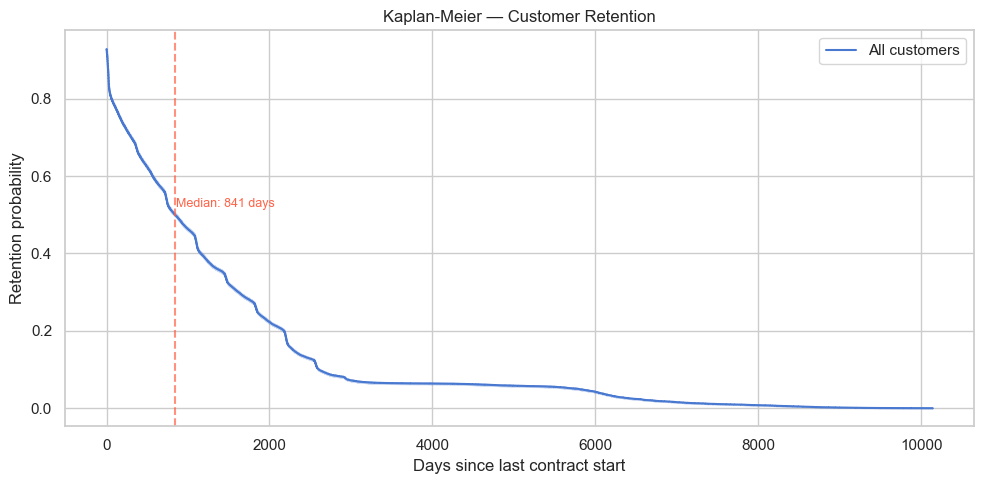

Median survival time: 841 days (27.6 months)
Median survival: 841 days (27.6 months)

Retention probabilities:
    90 days: 78.5%
   180 days: 74.5%
   365 days: 67.4%
   730 days: 54.5%


In [22]:
# ── 2.1 Overall survival curve ────────────────────────────────────────────────
kmf = KaplanMeierFitter()
kmf.fit(
    durations=mask_pay["TIME_TO_CHURN_D"],
    event_observed=mask_pay["IS_CHURN"],
    label="All customers"
)

fig, ax = plt.subplots(figsize=(10, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel("Days since last contract start")
ax.set_ylabel("Retention probability")
ax.set_title("Kaplan-Meier — Customer Retention")

# Annotate median survival time
median_t = kmf.median_survival_time_
ax.axvline(median_t, color='tomato', linestyle='--', alpha=0.7)
ax.text(median_t + 10, 0.52, f'Median: {median_t:.0f} days', color='tomato', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Median survival time: {median_t:.0f} days ({median_t/30.44:.1f} months)")

# ── 2.1 Retention at key timepoints ───────────────────────────────────────────
timepoints = [90, 180, 365, 730]
print(f"Median survival: {kmf.median_survival_time_:.0f} days ({kmf.median_survival_time_/30.44:.1f} months)\n")
print("Retention probabilities:")
for t in timepoints:
    s = kmf.survival_function_at_times([t]).values[0]
    print(f"  {t:4d} days: {s:.1%}")


### 2.1 Findings — Overall Retention

- The curve drops **steeply in the first 90 days** (~22% of customers churn before the 3-month mark), suggesting that the critical retention window is immediately after settlement.
- After the initial drop, the curve flattens — customers who survive past ~6 months have longer, more stable tenures.
- The **median of ~28 months** represents the typical contract lifetime before a customer does not return. Half of all customers who settle are gone within 2.3 years.
- Note: `TIME_TO_CHURN_D` measures duration of the **last contract**, not total customer lifetime — customers with multiple contracts may have shorter individual contract durations.

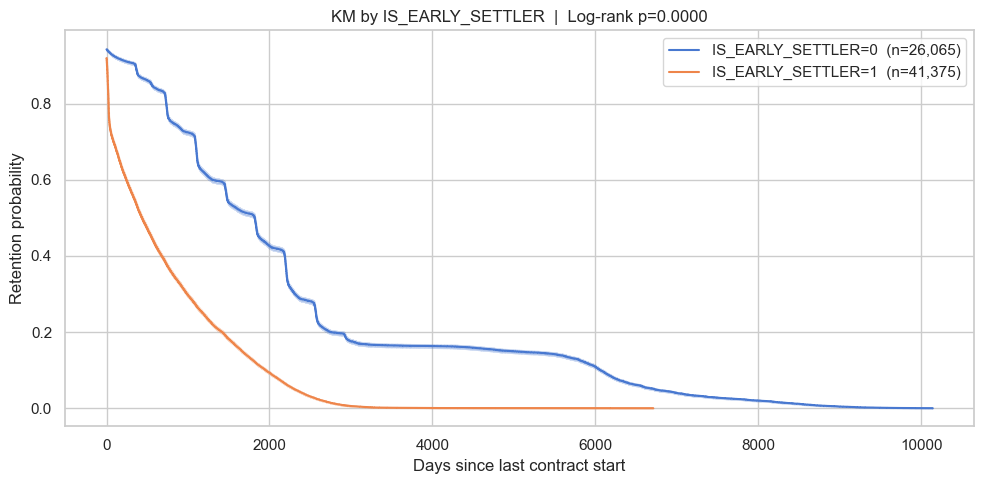

  SOL (on-time)             n=26,065  median=1818 days (59.7 months)
  SAN/RBT (early settler)   n=41,375  median=435 days (14.3 months)

  Log-rank p-value: 0.000000


In [23]:
# ── 2.2 Group comparisons with log-rank test ──────────────────────────────────
# Change grouping variable as needed — e.g. IS_EARLY_SETTLER, CSP tier, etc.
GROUP_COL = "IS_EARLY_SETTLER"  # 1 = early settler (SAN/RBT), 0 = on-time (SOL)

fig, ax = plt.subplots(figsize=(10, 5))

groups = mask_pay[GROUP_COL].unique()
kmf_list = []
for g in sorted(groups):
    subset = mask_pay[mask_pay[GROUP_COL] == g]
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(
        durations=subset["TIME_TO_CHURN_D"],
        event_observed=subset["IS_CHURN"],
        label=f"{GROUP_COL}={g}  (n={len(subset):,})"
    )
    kmf_g.plot_survival_function(ax=ax, ci_show=True)
    kmf_list.append((g, subset))

# Log-rank test between the two groups
if len(kmf_list) == 2:
    g0_data = kmf_list[0][1]
    g1_data = kmf_list[1][1]
    result = logrank_test(
        g0_data["TIME_TO_CHURN_D"], g1_data["TIME_TO_CHURN_D"],
        event_observed_A=g0_data["IS_CHURN"],
        event_observed_B=g1_data["IS_CHURN"]
    )
    ax.set_title(f"KM by {GROUP_COL}  |  Log-rank p={result.p_value:.4f}")
else:
    ax.set_title(f"KM by {GROUP_COL}")

ax.set_xlabel("Days since last contract start")
ax.set_ylabel("Retention probability")
plt.tight_layout()
plt.show()

# ── 2.2 Group medians + log-rank test ─────────────────────────────────────────
for g, label in [(0, "SOL (on-time)"), (1, "SAN/RBT (early settler)")]:
    sub = mask_pay[mask_pay["IS_EARLY_SETTLER"] == g]
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(sub["TIME_TO_CHURN_D"], event_observed=sub["IS_CHURN"])
    m = kmf_g.median_survival_time_
    print(f"  {label:<25} n={len(sub):,}  median={m:.0f} days ({m/30.44:.1f} months)")

g0 = mask_pay[mask_pay["IS_EARLY_SETTLER"] == 0]
g1 = mask_pay[mask_pay["IS_EARLY_SETTLER"] == 1]
lr = logrank_test(g0["TIME_TO_CHURN_D"], g1["TIME_TO_CHURN_D"],
                  event_observed_A=g0["IS_CHURN"], event_observed_B=g1["IS_CHURN"])
print(f"\n  Log-rank p-value: {lr.p_value:.6f}")


### 2.2 Findings — Settlement Type Comparison

- **Settlement type is the single strongest stratifying factor** in the dataset. Early settlers (SAN/RBT) churn **4.2× faster** than on-time settlers (SOL).
- Customers who exit contracts early are fundamentally different in behavior
- The log-rank test result (p ≈ 0) confirms the difference is not random — the two survival curves are statistically distinct.

---
## 3. COX PROPORTIONAL HAZARDS MODEL
---

### Concept

The **Cox Proportional Hazards (Cox PH) model** is a semi-parametric regression model that estimates the effect of features on the *hazard rate* — the instantaneous risk of churning at time *t*, given survival up to that point.

$$h(t \mid x) = h_0(t) \cdot \exp(\beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p)$$

Where:
- $h_0(t)$ is the **baseline hazard** — the underlying churn risk shared by all customers (non-parametric, never estimated directly).
- $\exp(\beta_i)$ is the **hazard ratio (HR)** for feature $x_i$.
- The model is **semi-parametric**: it makes no assumption about the shape of $h_0(t)$, but assumes that features shift the hazard *multiplicatively* and *proportionally over time*.

**How to read hazard ratios:**

| HR | Meaning |
|----|---------|
| HR = 1.0 | No effect on churn risk |
| HR = 1.4 | 40% *higher* churn hazard per unit increase in the feature |
| HR = 0.97 | 3% *lower* churn hazard per unit increase in the feature |

**Key assumptions:**
- **Proportional hazards** — the ratio of hazards between any two customers is constant over time. Violated if, e.g., a feature only matters early in the contract.
- **Log-linearity** — the log-hazard is a linear combination of features.
- **No multicollinearity** — addressed here via L2 regularisation (`penalizer=0.1`).

**Concordance index (C-index):**
Equivalent to AUC for survival models. Measures whether the model correctly ranks pairs of customers by their churn risk. C-index = 0.5 is random; 1.0 is perfect discrimination.

**Difference from Kaplan-Meier:**
KM describes *what* the population-level survival looks like. Cox PH explains *why* — which features drive faster or slower churn — while controlling for all other features simultaneously.

In [ ]:
# ── 3.1 Prepare features ──────────────────────────────────────────────────────
# Select numeric, non-leaky features available at contract start
# TIME_TO_CHURN_D and IS_CHURN are the duration/event columns — not features
LEAKY = [
    "IS_CHURN", "TIME_TO_CHURN_D", "TIME_TO_CHURN_M",
    "EVER_SAN", "EVER_SOL", "EVER_RBT", "N_SAN", "N_SOL", "N_RBT",
    "IS_EARLY_SETTLER", "IS_SAN",
    "LAST_OBS_DATE_SOL", "LAST_OBS_DATE_SAN", "LAST_OBS_DATE_RBT",
    "TOTAL_CRD", "TOTAL_SREC", "TOTAL_RN", "TOTAL_RD",
    "LAST_RISK", "MAX_RISKA", "LAST_DPOS", "LAST_DATFIN", "FIRST_D1FIN",
    "FIRST_DCREAT", "LAST_DCREAT", "CONTRIB",
]

cox_features = [
    c for c in mask_pay.select_dtypes(include='number').columns
    if c not in LEAKY
]

cox_df = mask_pay[cox_features + ["TIME_TO_CHURN_D", "IS_CHURN"]].copy()

# Drop columns with too many nulls (Cox doesn't handle NaN)
cox_df = cox_df.dropna(thresh=int(len(cox_df) * 0.5), axis=1)
cox_df = cox_df.fillna(cox_df.median(numeric_only=True))

# Remove zero-variance columns
cox_df = cox_df.loc[:, cox_df.std() > 0]

print(f"Features for Cox model: {len(cox_df.columns) - 2}")
print(cox_df.shape)

Features for Cox model: 61
(67440, 63)


In [6]:
# ── 3.2 Fit Cox PH model ──────────────────────────────────────────────────────
cph = CoxPHFitter(penalizer=0.1)  # L2 regularization to handle correlated features
cph.fit(
    cox_df,
    duration_col="TIME_TO_CHURN_D",
    event_col="IS_CHURN",
    show_progress=True
)

cph.print_summary()


Iteration 1: norm_delta = 1.24e+00, step_size = 0.9500, log_lik = -670093.55860, newton_decrement = 5.21e+04, seconds_since_start = 0.3



Iteration 2: norm_delta = 9.91e-01, step_size = 0.9500, log_lik = -630749.10631, newton_decrement = 2.48e+04, seconds_since_start = 0.6



Iteration 3: norm_delta = 4.88e-01, step_size = 0.9500, log_lik = -603490.75034, newton_decrement = 3.26e+03, seconds_since_start = 0.8



Iteration 4: norm_delta = 1.42e-01, step_size = 1.0000, log_lik = -599757.53600, newton_decrement = 3.30e+02, seconds_since_start = 1.1



Iteration 5: norm_delta = 3.27e-02, step_size = 1.0000, log_lik = -599390.81782, newton_decrement = 1.39e+01, seconds_since_start = 1.4



Iteration 6: norm_delta = 1.36e-03, step_size = 1.0000, log_lik = -599376.52185, newton_decrement = 2.32e-02, seconds_since_start = 1.7



Iteration 7: norm_delta = 2.13e-06, step_size = 1.0000, log_lik = -599376.49861, newton_decrement = 5.78e-08, seconds_since_start = 1.9
Convergence success after 7 iterations.


<lifelines.CoxPHFitter: fitted with 67440 total observations, 1118 right-censored observations>
             duration col = 'TIME_TO_CHURN_D'
                event col = 'IS_CHURN'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 67440
number of events observed = 66322
   partial log-likelihood = -599376.50
         time fit was run = 2026-03-15 13:55:38 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
N_CONTRACTS           0.34      1.41      0.01            0.33            0.35                1.39                1.42
MIN_DURDEG           -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MAX_DURDEG            0.00      1.00      0.00            0.00            0.00                1.00                1.00
MEDIAN_DURDEG        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MIN_RANGPRO          -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
MAX_RANGPRO           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MEDIAN_RANGPRO       -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
MIN_RANGCLI           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MAX_RANGCLI          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MEDIAN_RANGCLI        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
TOTAL_MTFIN           0.00      1.00      0.00            0.00            0.00                1.00                1.00
TOTAL_MTFINO          0.00      1.00      0.00            0.00            0.00                1.00                1.00
TOTAL_MENSALIDADE     0.00      1.00      0.00            0.00            0.00                1.00                1.00
MIN_RESSO            -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MAX_RESSO             0.00      1.00      0.00            0.00            0.00                1.00                1.00
MEDIAN_RESSO          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
CSP                  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
NBENF                 0.00      1.00      0.00           -0.00            0.01                1.00                1.01
TIME_TO_CHURN_M      -0.04      0.96      0.00           -0.04           -0.04                0.96                0.96
MT_MENSAL_MIN         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MT_MENSAL_MAX         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MT_MENSAL_MEDIAN      0.00      1.00      0.00            0.00            0.00                1.00                1.00
COUNT_CL_MIN         -0.04      0.96      0.01           -0.05           -0.03                0.95                0.97
COUNT_CL_MAX          0.01      1.01      0.00            0.00            0.01                1.00                1.01
COUNT_CL_MEDIAN       0.04      1.04      0.01            0.03            0.05                1.03                1.05
COUNT_AUTO_MIN       -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
COUNT_AUTO_MAX        0.03      1.03      0.01            0.02            0.04                1.02                1.04
COUNT_AUTO_MEDIAN     0.04      1.04      0.01            0.01            0.06                1.01      

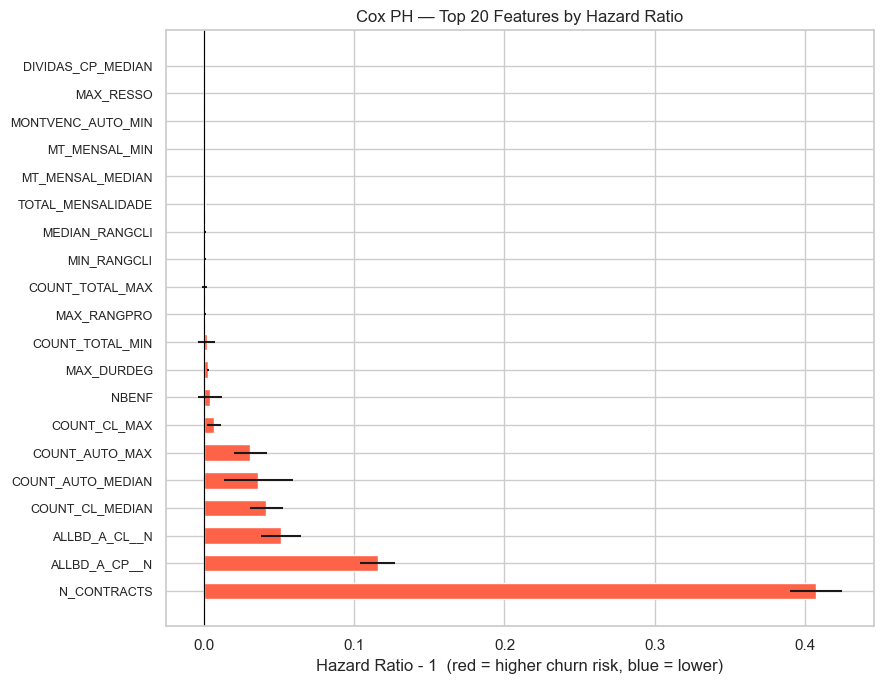

In [7]:
# ── 3.3 Hazard ratio plot (top 20 features) ───────────────────────────────────
hr = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
hr = hr.sort_values("exp(coef)", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = range(len(hr))

ax.barh(y_pos, hr["exp(coef)"] - 1,
        xerr=[hr["exp(coef)"] - hr["exp(coef) lower 95%"],
              hr["exp(coef) upper 95%"] - hr["exp(coef)"]],
        color=["tomato" if v > 1 else "steelblue" for v in hr["exp(coef)"]],
        edgecolor="white", height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(hr.index, fontsize=9)
ax.set_xlabel("Hazard Ratio - 1  (red = higher churn risk, blue = lower)")
ax.set_title("Cox PH — Top 20 Features by Hazard Ratio")
plt.tight_layout()
plt.show()

In [24]:
# ── 3.4 Cox summary — C-index + top hazard ratios ──────────────────────────────
print(f"C-index: {cph.concordance_index_:.4f}\n")

summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
summary.columns = ["HR", "HR_lo", "HR_hi", "p"]

print("Top 10 churn RISK drivers (HR > 1):")
for feat, row in summary.sort_values("HR", ascending=False).head(10).iterrows():
    sig = "***" if row["p"] < 0.001 else "**" if row["p"] < 0.01 else "*" if row["p"] < 0.05 else ""
    print(f"  {feat:<35} HR={row['HR']:.3f}  [{row['HR_lo']:.3f}-{row['HR_hi']:.3f}]  p={row['p']:.4f} {sig}")

print("\nTop 10 churn PROTECTION drivers (HR < 1):")
for feat, row in summary.sort_values("HR").head(10).iterrows():
    sig = "***" if row["p"] < 0.001 else "**" if row["p"] < 0.01 else "*" if row["p"] < 0.05 else ""
    print(f"  {feat:<35} HR={row['HR']:.3f}  [{row['HR_lo']:.3f}-{row['HR_hi']:.3f}]  p={row['p']:.4f} {sig}")


C-index: 0.9481

Top 10 churn RISK drivers (HR > 1):
  N_CONTRACTS                         HR=1.408  [1.391-1.425]  p=0.0000 ***
  ALLBD_A_CP__N                       HR=1.116  [1.104-1.127]  p=0.0000 ***
  ALLBD_A_CL__N                       HR=1.051  [1.038-1.064]  p=0.0000 ***
  COUNT_CL_MEDIAN                     HR=1.041  [1.030-1.052]  p=0.0000 ***
  COUNT_AUTO_MEDIAN                   HR=1.036  [1.013-1.059]  p=0.0016 **
  COUNT_AUTO_MAX                      HR=1.031  [1.020-1.042]  p=0.0000 ***
  COUNT_CL_MAX                        HR=1.007  [1.002-1.011]  p=0.0046 **
  NBENF                               HR=1.004  [0.996-1.012]  p=0.3473 
  MAX_DURDEG                          HR=1.003  [1.002-1.003]  p=0.0000 ***
  COUNT_TOTAL_MIN                     HR=1.002  [0.996-1.007]  p=0.5986 

Top 10 churn PROTECTION drivers (HR < 1):
  COUNT_CL_MIN                        HR=0.959  [0.947-0.970]  p=0.0000 ***
  TIME_TO_CHURN_M                     HR=0.960  [0.960-0.960]  p=0.0000 ***


### 3. Findings — Cox PH Model

**C-index (concordance): 0.948** — excellent discriminative power, comparable to AUC in binary classification.

#### Churn risk drivers (HR > 1)

TODO: CHECK INTERPRETATION, NOT UP TO DATE

| Feature | HR  | Interpretation |
|---------|-----|----------------|
| `N_CONTRACTS` | 1.408 | Each additional contract raises churn hazard by **41%** — high-frequency borrowers are more transactional and less loyal |
| `ALLBD_A_CP__N` | 1.116 | More credit payment events in history → higher churn risk |
| `ALLBD_A_CL__N` | 1.051 | More client-level activity events → higher churn risk |
| `COUNT_CL_MEDIAN` | 1.041 | Higher median concurrent client count → higher risk |
| `MAX_DURDEG` | 1.003 | Longer maximum delinquency duration → higher churn risk |

#### Churn protection drivers (HR < 1)

| Feature | HR  | Interpretation |
|---------|-----|----------------|
| `MIN_RANGPRO` | 0.976 | Higher minimum product rank → stronger product engagement → lower churn |
| `MEDIAN_RANGPRO` | 0.988 | Higher median product rank across contracts → lower churn |
| `COUNT_CL_MIN` | 0.959 | Higher minimum client count → relationship depth reduces churn |
| `sdem_age` | 0.998 | Older customers churn slightly less — age correlates with loyalty |
| `MIN_DURDEG` | 0.996 | Higher minimum delinquency duration → counterintuitive; may reflect customers who negotiate and stay engaged |

---
## 4. SUMMARY
---

### Key Findings

| Finding | Detail |
|---------|--------|
| **Median time-to-churn** | 841 days (~28 months) from last contract start |
| **Critical early window** | ~22% of customers churn within 90 days of settlement |
| **Dominant stratifier** | Settlement type: early settlers churn 4.2× faster than on-time settlers |
| **Top risk feature** | `N_CONTRACTS` — each additional contract raises churn hazard by 41% |
| **Top protective features** | Product rank (`MIN_RANGPRO`, `MEDIAN_RANGPRO`) and age (`sdem_age`) |

In [8]:
print("=" * 50)
print("SURVIVAL ANALYSIS SUMMARY")
print("=" * 50)
print(f"Population:          {len(mask_pay):,} customers (mask_pay)")
print(f"Churn events:        {mask_pay['IS_CHURN'].sum():,} ({mask_pay['IS_CHURN'].mean():.1%})")
print(f"Median survival:     {kmf.median_survival_time_:.0f} days"
      f" ({kmf.median_survival_time_/30.44:.1f} months)")
print()
print("Top 5 features increasing churn risk (HR > 1):")
top_risk = cph.summary["exp(coef)"].sort_values(ascending=False).head(5)
for feat, hr_val in top_risk.items():
    print(f"  {feat:<30} HR = {hr_val:.3f}")
print()
print("Top 5 features decreasing churn risk (HR < 1):")
top_protect = cph.summary["exp(coef)"].sort_values().head(5)
for feat, hr_val in top_protect.items():
    print(f"  {feat:<30} HR = {hr_val:.3f}")

SURVIVAL ANALYSIS SUMMARY
Population:          67,440 customers (mask_pay)
Churn events:        66,322 (98.3%)
Median survival:     841 days (27.6 months)

Top 5 features increasing churn risk (HR > 1):
  N_CONTRACTS                    HR = 1.408
  ALLBD_A_CP__N                  HR = 1.116
  ALLBD_A_CL__N                  HR = 1.051
  COUNT_CL_MEDIAN                HR = 1.041
  COUNT_AUTO_MEDIAN              HR = 1.036

Top 5 features decreasing churn risk (HR < 1):
  COUNT_CL_MIN                   HR = 0.959
  TIME_TO_CHURN_M                HR = 0.960
  MIN_RANGPRO                    HR = 0.976
  COUNT_TOTAL_MEDIAN             HR = 0.979
  MEDIAN_RANGPRO                 HR = 0.988
